# Proyek Analisis Data: Air Quality Dataset

- **Nama:** Muhammad Abiya Makruf
- **Email:** aabbiiyyaa@gmail.com
- **ID Dicoding:** abiyamf

Notebook ini menganalisis kualitas udara di stasiun **Aotizhongxin** menggunakan dataset `PRSA_Data_Aotizhongxin_20130301-20170228.csv`. Fokus analisis diarahkan pada hubungan pola cuaca, musim, arah angin, dan tingkat polusi untuk menghasilkan insight yang dapat digunakan sebagai bahan monitoring lingkungan.

## Menentukan Pertanyaan Bisnis

1. Pada bulan apa curah hujan tertinggi terjadi setiap tahun, dan bagaimana pola temperatur bulanan berubah sepanjang periode pengamatan?
2. Kapan tingkat polusi `PM2.5` cenderung lebih tinggi jika dilihat dari musim dan arah angin?
3. Bagaimana distribusi kategori kualitas udara berbasis `PM2.5`, dan seberapa sering kondisi tidak sehat muncul pada tiap tahun?

## Import Semua Packages/Library yang Digunakan

Library yang dipakai mencakup `pandas` untuk pengolahan data, `matplotlib` dan `seaborn` untuk visualisasi, serta `pathlib` untuk memastikan path file tetap konsisten saat notebook dijalankan dari root proyek.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

## Data Wrangling

Tahap ini mencakup proses pengumpulan data, pemeriksaan kualitas data, dan pembersihan data yang relevan untuk analisis time series kualitas udara.

### Gathering Data

Dataset dibaca langsung dari folder `data/` agar notebook dapat dijalankan di lingkungan lokal proyek, bukan bergantung pada path khusus seperti Google Colab. Pada tahap ini saya juga memastikan file yang digunakan memang berasal dari dataset resmi submission dan siap diproses pada tahapan berikutnya.


In [2]:
BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / 'data' / 'PRSA_Data_Aotizhongxin_20130301-20170228.csv'

df_raw = pd.read_csv(DATA_PATH)
df_raw.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


#### Rangkuman Insight Tahap Gathering Data

- Dataset yang digunakan berasal dari file resmi Air Quality Dataset dan terfokus pada stasiun `Aotizhongxin`.
- Struktur data bersifat time series per jam, sehingga analisis selanjutnya perlu mempertahankan urutan waktu dan konsistensi agregasi bulanan/musiman.
- Tahap gathering memastikan sumber data, lokasi file, dan konteks observasi sudah sesuai sebelum masuk ke pemeriksaan kualitas data.


### Assessing Data

Pemeriksaan awal dilakukan untuk memahami struktur data, mendeteksi missing values, dan memastikan tidak ada duplikasi penuh yang dapat mengganggu analisis. Tahap ini penting karena strategi cleaning harus didasarkan pada kondisi data yang benar-benar ditemukan, bukan asumsi.


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34139 non-null  float64
 6   PM10     34346 non-null  float64
 7   SO2      34129 non-null  float64
 8   NO2      34041 non-null  float64
 9   CO       33288 non-null  float64
 10  O3       33345 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34983 non-null  str    
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  str    
dtypes: float64(11), int64(5), str(2)
memory usage: 5.3 MB


In [4]:
missing_values = df_raw.isna().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

CO       1776
O3       1719
NO2      1023
SO2       935
PM2.5     925
PM10      718
wd         81
RAIN       20
DEWP       20
PRES       20
TEMP       20
WSPM       14
dtype: int64

In [5]:
print(f'Jumlah duplikasi penuh: {df_raw.duplicated().sum()}')

Jumlah duplikasi penuh: 0


In [6]:
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
No,35064.0,NaN,NaN,NaN,17532.5,10122.249256,1.0,8766.75,17532.5,26298.25,35064.0
year,35064.0,NaN,NaN,NaN,2014.66256,1.177213,2013.0,2014.0,2015.0,2016.0,2017.0
month,35064.0,NaN,NaN,NaN,6.52293,3.448752,1.0,4.0,7.0,10.0,12.0
day,35064.0,NaN,NaN,NaN,15.729637,8.800218,1.0,8.0,16.0,23.0,31.0
hour,35064.0,NaN,NaN,NaN,11.5,6.922285,0.0,5.75,11.5,17.25,23.0
PM2.5,34139.0,NaN,NaN,NaN,82.773611,82.135694,3.0,22.0,58.0,114.0,898.0
PM10,34346.0,NaN,NaN,NaN,110.060391,95.223005,2.0,38.0,87.0,155.0,984.0
SO2,34129.0,NaN,NaN,NaN,17.375901,22.823017,0.2856,3.0,9.0,21.0,341.0
NO2,34041.0,NaN,NaN,NaN,59.305833,37.1162,2.0,30.0,53.0,82.0,290.0
CO,33288.0,NaN,NaN,NaN,1262.945145,1221.436236,100.0,500.0,900.0,1500.0,10000.0


#### Rangkuman Insight Tahap Assessing Data

- Dataset memiliki 35.064 baris dan 18 kolom, sehingga cukup memadai untuk analisis pola cuaca dan polusi dari 2013 sampai 2017.
- Ditemukan missing values pada beberapa kolom numerik seperti `CO`, `O3`, `NO2`, dan `PM2.5`, tetapi tidak ditemukan duplikasi penuh.
- Temuan ini menunjukkan bahwa masalah utama data ada pada nilai hilang, bukan duplikasi atau struktur file yang rusak.


### Cleaning Data

Strategi cleaning disesuaikan dengan karakter data. Kolom numerik diinterpolasi karena dataset berbentuk deret waktu per jam, sedangkan kolom arah angin (`wd`) diisi menggunakan modus karena bersifat kategorikal. Setelah itu, ditambahkan fitur turunan yang akan dipakai pada analisis lanjutan.


In [7]:
df = df_raw.copy()

numeric_columns = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
df[numeric_columns] = df[numeric_columns].interpolate(limit_direction='both')
df['wd'] = df['wd'].fillna(df['wd'].mode()[0])
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

season_map = {12: 'Winter', 1: 'Winter', 2: 'Winter', 3: 'Spring', 4: 'Spring', 5: 'Spring', 6: 'Summer', 7: 'Summer', 8: 'Summer', 9: 'Autumn', 10: 'Autumn', 11: 'Autumn'}
pollution_labels = ['Baik', 'Sedang', 'Tidak Sehat untuk Sensitif', 'Tidak Sehat', 'Sangat Tidak Sehat']
pollution_bins = [-1, 35, 75, 115, 150, np.inf]

df['season'] = df['month'].map(season_map)
df['pollution_category'] = pd.cut(df['PM2.5'], bins=pollution_bins, labels=pollution_labels)
df[['datetime', 'season', 'pollution_category']].head()

,datetime,season,pollution_category
0,2013-03-01 00:00:00,Spring,Baik
1,2013-03-01 01:00:00,Spring,Baik
2,2013-03-01 02:00:00,Spring,Baik
3,2013-03-01 03:00:00,Spring,Baik
4,2013-03-01 04:00:00,Spring,Baik


In [8]:
df.isna().sum().sort_values(ascending=False).head(10)

No       0
year     0
month    0
day      0
hour     0
PM2.5    0
PM10     0
SO2      0
NO2      0
CO       0
dtype: int64

#### Rangkuman Insight Tahap Cleaning Data

- Interpolasi numerik cocok digunakan karena data dicatat per jam dan memiliki kontinuitas waktu yang kuat.
- Pengisian `wd` dengan modus menjaga kelengkapan kolom kategorikal tanpa mengubah pola mayoritas arah angin secara ekstrem.
- Setelah cleaning, data siap dipakai untuk analisis lanjutan karena missing values utama sudah ditangani dan fitur turunan seperti `datetime`, `season`, dan `pollution_category` sudah tersedia.


## Exploratory Data Analysis (EDA)

Agregasi dibuat untuk menjawab pertanyaan bisnis secara langsung. Saya menyusun ringkasan bulanan, musiman, arah angin, dan kategori polusi agar analisis tidak berhenti pada statistik deskriptif dasar saja. Pada tahap ini fokusnya adalah membentuk pola-pola inti yang nanti akan dipertegas lagi melalui visualisasi dan explanatory analysis.


In [9]:
monthly_weather = (
    df.groupby(['year', 'month'], as_index=False)
    .agg(total_rain=('RAIN', 'sum'), avg_temp=('TEMP', 'mean'), avg_pm25=('PM2.5', 'mean'))
)
monthly_weather['avg_temp'] = monthly_weather['avg_temp'].round(2)
monthly_weather['avg_pm25'] = monthly_weather['avg_pm25'].round(2)

peak_rain_by_year = monthly_weather.loc[monthly_weather.groupby('year')['total_rain'].idxmax()].sort_values('year')

temperature_extremes = []
for year, part in monthly_weather.groupby('year'):
    coldest = part.loc[part['avg_temp'].idxmin()]
    hottest = part.loc[part['avg_temp'].idxmax()]
    temperature_extremes.append({
        'year': year,
        'coldest_month': int(coldest['month']),
        'coldest_avg_temp': round(float(coldest['avg_temp']), 2),
        'hottest_month': int(hottest['month']),
        'hottest_avg_temp': round(float(hottest['avg_temp']), 2),
    })

temperature_extremes = pd.DataFrame(temperature_extremes)

peak_rain_by_year

,year,month,total_rain,avg_temp,avg_pm25
4,2013,7,218.6,26.88,68.91
15,2014,6,189.5,24.59,60.01
28,2015,7,201.0,26.40,66.29
40,2016,7,315.0,27.70,71.14
47,2017,2,4.1,2.66,70.93


In [10]:
temperature_extremes

,year,coldest_month,coldest_avg_temp,hottest_month,hottest_avg_temp
0,2013,12,-0.16,7,26.88
1,2014,12,-0.65,7,27.81
2,2015,1,-0.71,8,26.44
3,2016,1,-4.55,8,27.86
4,2017,1,-1.14,2,2.66


In [11]:
season_pollution = (
    df.groupby('season', as_index=False)
    .agg(avg_pm25=('PM2.5', 'mean'), avg_pm10=('PM10', 'mean'), avg_rain=('RAIN', 'mean'))
    .round(2)
)

wind_pollution = (
    df.groupby('wd', as_index=False)
    .agg(avg_pm25=('PM2.5', 'mean'), observations=('wd', 'size'))
    .query('observations >= 500')
    .sort_values('avg_pm25', ascending=False)
)

pollution_distribution = (
    df['pollution_category']
    .value_counts(normalize=True)
    .rename('share_pct')
    .mul(100)
    .round(2)
    .reindex(pollution_labels)
)

yearly_pollution_mix = (
    df.groupby(['year', 'pollution_category'])
    .size()
    .rename('count')
    .reset_index()
)
yearly_pollution_mix['share_pct'] = (
    yearly_pollution_mix['count'] / yearly_pollution_mix.groupby('year')['count'].transform('sum') * 100
).round(2)

season_pollution

,season,avg_pm25,avg_pm10,avg_rain
0,Autumn,86.84,110.51,0.06
1,Spring,81.95,132.50,0.03
2,Summer,67.32,81.24,0.18
3,Winter,94.32,116.71,0.00


In [12]:
wind_pollution.head(10)

,wd,avg_pm25,observations
0,E,108.119806,2608
2,ESE,106.033721,1717
1,ENE,104.681344,3950
9,SE,99.666272,1341
10,SSE,97.932937,1022
8,S,94.362386,1304
4,NE,93.389799,5221
11,SSW,86.435106,2098
12,SW,79.714761,3359
13,W,74.331693,1171


In [13]:
pollution_distribution

pollution_category
Baik                          35.50
Sedang                        24.06
Tidak Sehat untuk Sensitif    15.84
Tidak Sehat                    8.58
Sangat Tidak Sehat            16.02
Name: share_pct, dtype: float64

#### Rangkuman Insight Tahap Exploratory Data Analysis

- Agregasi bulanan menunjukkan pola hujan dan temperatur yang cukup konsisten antar tahun.
- Agregasi musiman dan arah angin mulai memperlihatkan bahwa variasi polusi tidak acak, tetapi berkaitan dengan konteks cuaca dan sirkulasi udara.
- Pembentukan distribusi kategori polusi pada tahap EDA membuat explanatory analysis nantinya dapat langsung menjawab proporsi kondisi aman versus berisiko.


## Visualization & Explanatory Analysis

Visualisasi berikut dirancang untuk menjawab setiap pertanyaan bisnis secara efektif, dengan fokus pada keterbacaan, perbandingan antar tahun, dan interpretasi yang mudah. Setiap grafik diikuti rangkuman insight agar hubungan antara visualisasi dan jawaban bisnis terlihat eksplisit.


### Pertanyaan 1: Pada bulan apa curah hujan tertinggi terjadi setiap tahun, dan bagaimana pola temperatur bulanan berubah sepanjang periode pengamatan?

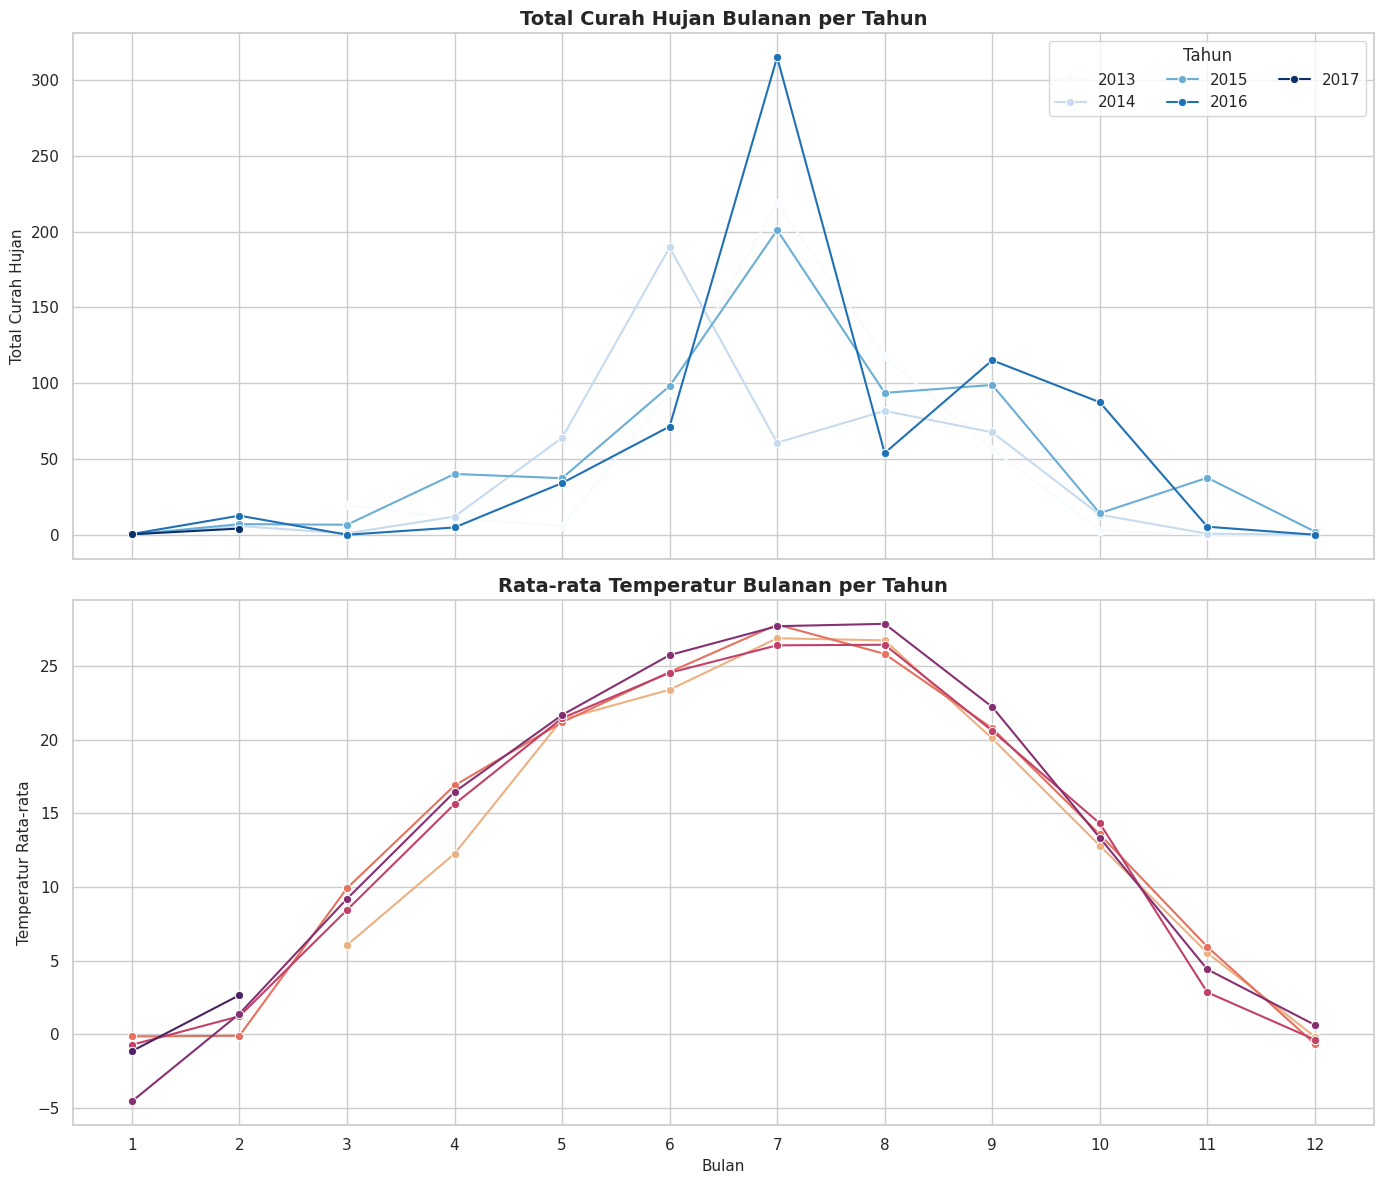

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

sns.lineplot(data=monthly_weather, x='month', y='total_rain', hue='year', marker='o', palette='Blues', ax=axes[0])
axes[0].set_title('Total Curah Hujan Bulanan per Tahun')
axes[0].set_xlabel('Bulan')
axes[0].set_ylabel('Total Curah Hujan')
axes[0].set_xticks(range(1, 13))
axes[0].legend(title='Tahun', ncol=3)

sns.lineplot(data=monthly_weather, x='month', y='avg_temp', hue='year', marker='o', palette='flare', ax=axes[1], legend=False)
axes[1].set_title('Rata-rata Temperatur Bulanan per Tahun')
axes[1].set_xlabel('Bulan')
axes[1].set_ylabel('Temperatur Rata-rata')
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

### Rangkuman Insight Explanatory Analysis 1

- Puncak curah hujan tahunan paling sering terkonsentrasi pada pertengahan tahun, khususnya Juni atau Juli.
- Temperatur rata-rata tertinggi cenderung muncul pada Juli atau Agustus, sedangkan temperatur terendah dominan pada Desember atau Januari.
- Pola ini menunjukkan bahwa dinamika cuaca tahunan di stasiun Aotizhongxin cukup konsisten dan layak dijadikan baseline pemantauan musiman.


### Pertanyaan 2: Kapan tingkat polusi `PM2.5` cenderung lebih tinggi jika dilihat dari musim dan arah angin?

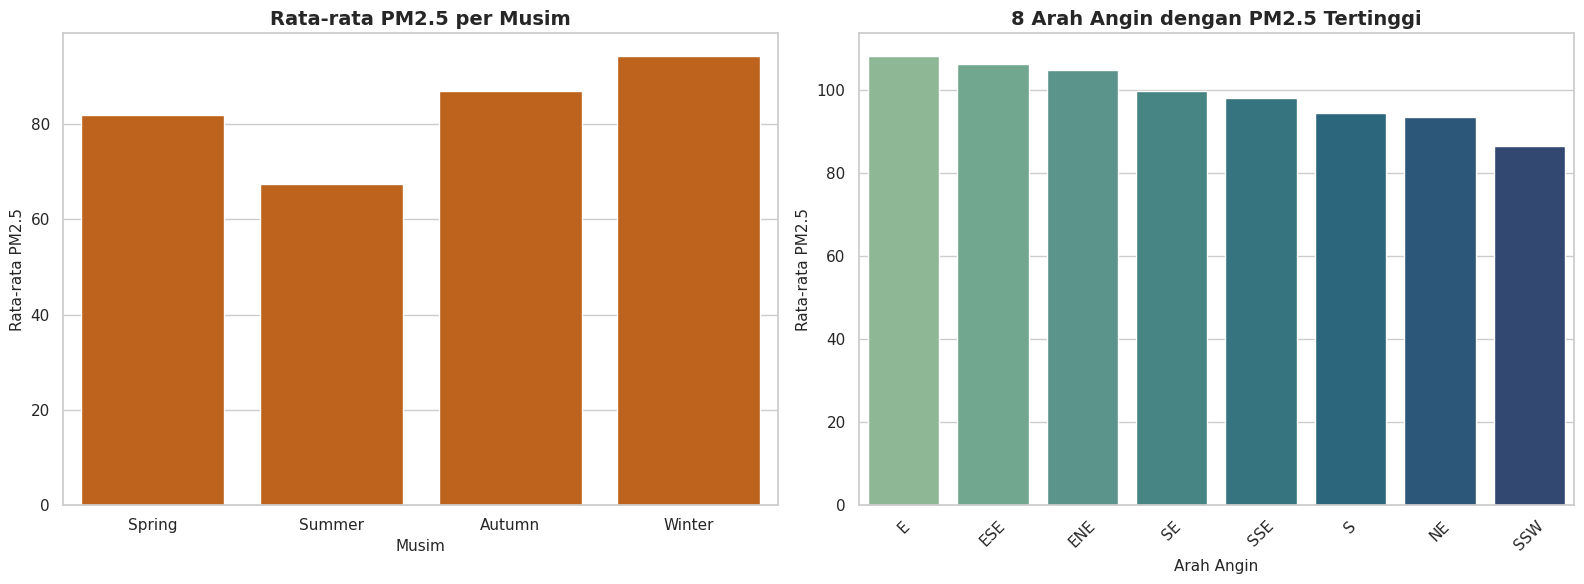

In [15]:
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=season_pollution, x='season', y='avg_pm25', order=season_order, color='#d95f02', ax=axes[0])
axes[0].set_title('Rata-rata PM2.5 per Musim')
axes[0].set_xlabel('Musim')
axes[0].set_ylabel('Rata-rata PM2.5')

top_wind_pollution = wind_pollution.head(8)
sns.barplot(data=top_wind_pollution, x='wd', y='avg_pm25', palette='crest', ax=axes[1])
axes[1].set_title('8 Arah Angin dengan PM2.5 Tertinggi')
axes[1].set_xlabel('Arah Angin')
axes[1].set_ylabel('Rata-rata PM2.5')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Rangkuman Insight Explanatory Analysis 2

- Grafik musiman menunjukkan bahwa kualitas udara cenderung memburuk pada musim `Winter`, lalu mulai menurun pada `Summer`.
- Grafik arah angin menunjukkan bahwa kelompok angin dari sektor timur seperti `E`, `ESE`, dan `ENE` berkaitan dengan rata-rata `PM2.5` yang lebih tinggi.
- Kombinasi dua insight ini membantu mempersempit kapan dan dalam kondisi seperti apa risiko polusi udara cenderung meningkat.


### Pertanyaan 3: Bagaimana distribusi kategori kualitas udara berbasis PM2.5, dan seberapa sering kondisi tidak sehat muncul pada tiap tahun?

Bagian ini merupakan **analisis lanjutan berbasis manual grouping/binning**. Teknik ini digunakan untuk mengelompokkan nilai `PM2.5` ke dalam lima kategori kualitas udara agar hasil analisis lebih mudah dipahami secara non-teknis dan lebih relevan untuk kebutuhan monitoring.

**Tujuan teknik analisis lanjutan ini:**
- menerjemahkan angka `PM2.5` mentah menjadi kategori kualitas udara yang lebih mudah diinterpretasikan;
- mengukur seberapa besar proporsi kondisi udara yang masih aman dibanding kondisi yang sudah berisiko;
- membantu melihat perubahan komposisi kualitas udara per tahun tanpa menggunakan algoritma machine learning.

Teknik ini relevan dengan dataset Air Quality karena variabel `PM2.5` adalah indikator utama pencemaran udara dan dapat dikelompokkan secara manual berdasarkan ambang kategori yang informatif.


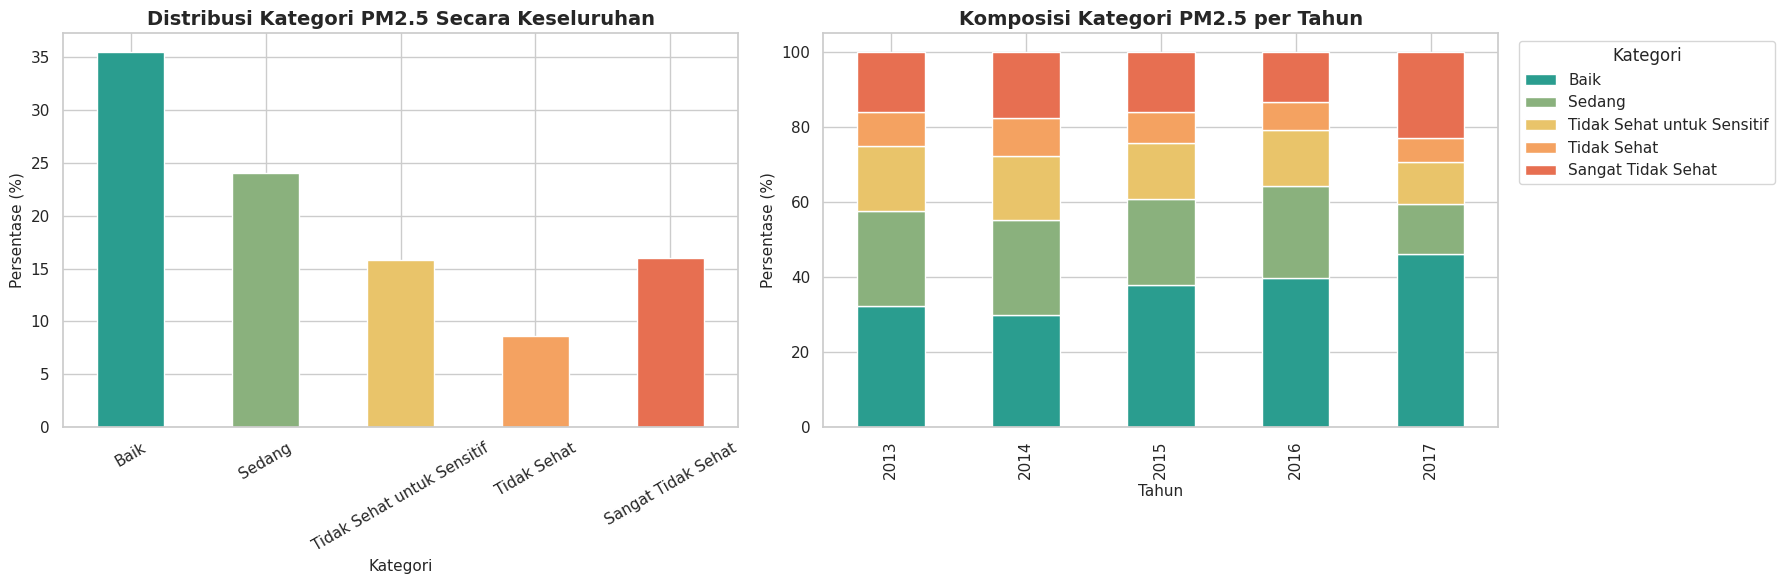

In [16]:
category_palette = ['#2a9d8f', '#8ab17d', '#e9c46a', '#f4a261', '#e76f51']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

pollution_distribution.reset_index().rename(columns={'index': 'pollution_category'}).plot(
    kind='bar', x='pollution_category', y='share_pct', color=category_palette, legend=False, ax=axes[0]
)
axes[0].set_title('Distribusi Kategori PM2.5 Secara Keseluruhan')
axes[0].set_xlabel('Kategori')
axes[0].set_ylabel('Persentase (%)')
axes[0].tick_params(axis='x', rotation=30)

category_pivot = (
    yearly_pollution_mix
    .pivot(index='year', columns='pollution_category', values='share_pct')
    .reindex(columns=pollution_labels)
    .fillna(0)
)
category_pivot.plot(kind='bar', stacked=True, color=category_palette, ax=axes[1])
axes[1].set_title('Komposisi Kategori PM2.5 per Tahun')
axes[1].set_xlabel('Tahun')
axes[1].set_ylabel('Persentase (%)')
axes[1].legend(title='Kategori', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Rangkuman Insight Explanatory Analysis 3

- Kategori `Baik` memang masih menjadi kelompok terbesar, tetapi proporsi kondisi berisiko tetap signifikan sehingga tidak bisa diabaikan.
- Komposisi kategori per tahun membantu melihat bahwa kualitas udara tidak selalu stabil pada level aman.

## Conclusion

1. **Pola hujan dan temperatur:** Puncak curah hujan tahunan paling sering muncul pada bulan Juni-Juli. Secara spesifik, puncak hujan terjadi pada Juli 2013 (218.6), Juni 2014 (189.5), Juli 2015 (201.0), dan Juli 2016 (315.0). Temperatur rata-rata tertinggi cenderung muncul pada Juli-Agustus, sedangkan temperatur terendah muncul pada Desember atau Januari.
2. **Musim dan arah angin yang berkaitan dengan polusi:** Rata-rata `PM2.5` tertinggi muncul pada **Winter (94.32)**, disusul **Autumn (86.84)**, sedangkan **Summer (67.32)** menjadi musim dengan polusi rata-rata paling rendah. Dari sisi arah angin, kelompok angin **E, ESE, dan ENE** menunjukkan rata-rata `PM2.5` tertinggi, semuanya di atas 104.
3. **Analisis lanjutan berbasis kategori polusi:** Secara keseluruhan, kategori **Baik** masih dominan sebesar **35.50%**, tetapi gabungan kondisi **Tidak Sehat untuk Sensitif**, **Tidak Sehat**, dan **Sangat Tidak Sehat** mencapai **40.44%**. Artinya, kejadian kualitas udara yang berisiko tetap sering muncul dan layak menjadi fokus pemantauan.

## Menyimpan Dataset Bersih untuk Dashboard

Dataset yang sudah dibersihkan dan diperkaya disimpan ke folder `dashboard/` agar aplikasi Streamlit memakai data yang konsisten dengan notebook analisis.

In [17]:
output_path = BASE_DIR / 'dashboard' / 'all_data.csv'
df.to_csv(output_path, index=False)
output_path

PosixPath('/mnt/c/Users/abiyamf/Documents/Code Program/Dicoding/Dicoding-BelajarFundamentalAnalisisData/dashboard/all_data.csv')